In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/Colab \Notebooks/microscopy_self_supervised_learning/microscopy_self_supervised_learning/

/content/drive/MyDrive/Colab Notebooks/microscopy_self_supervised_learning/microscopy_self_supervised_learning


Imports & setup

In [31]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from skimage.io import imread
from skimage.transform import resize
import cv2

from sklearn.preprocessing import LabelEncoder, StandardScaler

Paths & metadata

In [4]:
metadata = pd.read_csv("data/processed/metadata_with_moa.csv")
metadata.tail(3)

,TableNumber,ImageNumber,Image_FileName_DAPI,Image_PathName_DAPI,Image_FileName_Tubulin,Image_PathName_Tubulin,Image_FileName_Actin,Image_PathName_Actin,plate,well,Replicate,compound,concentration,moa
3845,9,3598,Week9_090907_G11_s2_w10B010F39-3B4B-4DCB-8E34-...,Week9_39301,Week9_090907_G11_s2_w2720AC778-3F85-4293-8D75-...,Week9_39301,Week9_090907_G11_s2_w49B290958-BCF2-4DDD-B0E9-...,Week9_39301,Week9_39301,G11,3,DMSO,0.0,DMSO
3846,9,3599,Week9_090907_G11_s3_w10394282C-6D3D-4E0E-9FA3-...,Week9_39301,Week9_090907_G11_s3_w24C59DB62-E99B-4284-BAD2-...,Week9_39301,Week9_090907_G11_s3_w471FE25C8-2477-456F-9D74-...,Week9_39301,Week9_39301,G11,3,DMSO,0.0,DMSO
3847,9,3600,Week9_090907_G11_s4_w1C447A151-1F85-4E19-9C96-...,Week9_39301,Week9_090907_G11_s4_w22E574F48-321D-4470-ACC4-...,Week9_39301,Week9_090907_G11_s4_w4200C5003-7F75-47DF-928C-...,Week9_39301,Week9_39301,G11,3,DMSO,0.0,DMSO


In [5]:
DATA_DIR = "data/raw"
RESULTS_DIR = "results/figures"
PROCESSED_DIR = "data/processed"

In [6]:
metadata['Image_FileName_DAPI'][0]

'Week1_150607_B04_s3_w135D66B4C-0548-4AB8-A57B-9CC39666813B.tif'

In [7]:
X = np.load("data/splits/X_images.npy")
y = np.load("data/splits/y_labels.npy")

print(X.shape)
print(y.shape)

(3845, 3, 128, 128)
(3845, 3)


Image loader function

In [8]:
from torch.utils.data import Dataset
import torch
class MicroscopyDataset(Dataset):

    def __init__(self, X):
        self.X = X

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return torch.tensor(self.X[idx], dtype=torch.float32)

In [9]:
from torch.utils.data import DataLoader

dataset = MicroscopyDataset(X)

dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

In [10]:
imgs = next(iter(dataloader))

print(imgs.shape)
print(imgs.min(), imgs.max())

torch.Size([64, 3, 128, 128])
tensor(0.0011) tensor(1.)


Autoencoder model

In [11]:
import torch
import torch.nn as nn

import torch
import torch.nn as nn

class Autoencoder(nn.Module):

    def __init__(self, latent_dim=256):
        super().__init__()

        self.encoder = nn.Sequential(

            nn.Conv2d(3,16,3,stride=2,padding=1),
            nn.ReLU(),

            nn.Conv2d(16,32,3,stride=2,padding=1),
            nn.ReLU(),

            nn.Conv2d(32,64,3,stride=2,padding=1),
            nn.ReLU(),

            nn.Flatten(),
            nn.Linear(64*16*16, latent_dim)
        )

        self.decoder_fc = nn.Linear(latent_dim, 64*16*16)

        self.decoder = nn.Sequential(

            nn.Upsample(scale_factor=2),
            nn.Conv2d(64,32,3,padding=1),
            nn.ReLU(),

            nn.Upsample(scale_factor=2),
            nn.Conv2d(32,16,3,padding=1),
            nn.ReLU(),

            nn.Upsample(scale_factor=2),
            nn.Conv2d(16,3,3,padding=1),
            nn.Sigmoid()
        )

    def forward(self,x):

        z = self.encoder(x)

        x = self.decoder_fc(z)
        x = x.view(-1,64,16,16)

        out = self.decoder(x)

        return out, z

Train setup

In [13]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [14]:
model = Autoencoder(latent_dim=256)

criterion = nn.L1Loss()

#weight decay
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

#scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=100
)

num_epochs = 120

Training loop

In [15]:
import torch
print(torch.cuda.is_available())
#print(torch.cuda.get_device_name(0))

False


In [16]:
train_losses = []

for epoch in range(num_epochs):

    model.train()
    running_loss = 0.0

    for imgs in dataloader:

        imgs = imgs.to(device)

        recon, _ = model(imgs)

        loss = criterion(recon, imgs)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    scheduler.step()

    epoch_loss = running_loss / len(dataloader)
    train_losses.append(epoch_loss)

    print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}")

Epoch 1, Loss: 0.1477
Epoch 2, Loss: 0.1199
Epoch 3, Loss: 0.1196
Epoch 4, Loss: 0.1187
Epoch 5, Loss: 0.1196
Epoch 6, Loss: 0.0968
Epoch 7, Loss: 0.0799
Epoch 8, Loss: 0.0741
Epoch 9, Loss: 0.0671
Epoch 10, Loss: 0.0612
Epoch 11, Loss: 0.0589
Epoch 12, Loss: 0.0563
Epoch 13, Loss: 0.0545
Epoch 14, Loss: 0.0534
Epoch 15, Loss: 0.0515
Epoch 16, Loss: 0.0507
Epoch 17, Loss: 0.0497
Epoch 18, Loss: 0.0482
Epoch 19, Loss: 0.0481
Epoch 20, Loss: 0.0465
Epoch 21, Loss: 0.0459
Epoch 22, Loss: 0.0448
Epoch 23, Loss: 0.0438
Epoch 24, Loss: 0.0428
Epoch 25, Loss: 0.0422
Epoch 26, Loss: 0.0406
Epoch 27, Loss: 0.0398
Epoch 28, Loss: 0.0384
Epoch 29, Loss: 0.0375
Epoch 30, Loss: 0.0365
Epoch 31, Loss: 0.0373
Epoch 32, Loss: 0.0355
Epoch 33, Loss: 0.0346
Epoch 34, Loss: 0.0338
Epoch 35, Loss: 0.0330
Epoch 36, Loss: 0.0326
Epoch 37, Loss: 0.0316
Epoch 38, Loss: 0.0316
Epoch 39, Loss: 0.0310
Epoch 40, Loss: 0.0305
Epoch 41, Loss: 0.0300
Epoch 42, Loss: 0.0296
Epoch 43, Loss: 0.0289
Epoch 44, Loss: 0.02

Plot training loss

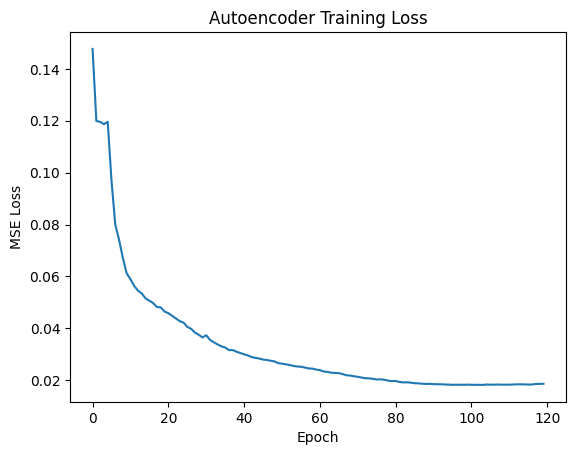

In [17]:
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Autoencoder Training Loss")
plt.savefig(f"{RESULTS_DIR}/autoencoder_loss.png")
plt.show()

Extract Embeddings

In [24]:
embeddings = []

model.eval()

with torch.no_grad():
    for imgs in dataloader:

        imgs = imgs.to(device)

        _, z = model(imgs)

        embeddings.append(z.cpu())

Downstream tasks

In [18]:
moa = y[:,0]
compound = y[:, 1]
concentration = y[:, 2]

In [19]:
replicate_groups = np.array([
    f"{c}_{d}" for c, d in zip(compound, concentration)
])

In [25]:
X_embeddings = torch.cat(embeddings, dim=0).numpy()

Reconstruction of an image

In [26]:
model.eval()

imgs = next(iter(dataloader))
imgs = imgs.to(device)

In [28]:
with torch.no_grad():
    recon, _ = model(imgs)

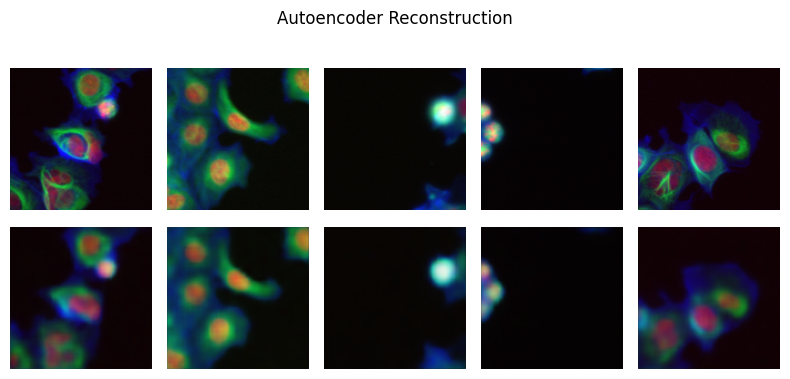

In [29]:
import matplotlib.pyplot as plt

def show(img):
    img = img.permute(1,2,0).cpu().numpy()
    img = img.clip(0,1)
    plt.imshow(img)
    plt.axis("off")

model.eval()

imgs = next(iter(dataloader)).to(device)

with torch.no_grad():
    recon, _ = model(imgs)

n = 5
plt.figure(figsize=(8,4))

for i in range(n):

    # original
    plt.subplot(2, n, i+1)
    show(imgs[i])
    if i == 0: plt.ylabel("Original")

    # reconstructed
    plt.subplot(2, n, i+1+n)
    show(recon[i])
    if i == 0: plt.ylabel("Reconstruction")

plt.suptitle("Autoencoder Reconstruction")
plt.tight_layout()
plt.show()

MOA Prediction

In [32]:
le = LabelEncoder()
y_enc = le.fit_transform(moa)

In [33]:
from sklearn.preprocessing import normalize
X_embeddings = normalize(X_embeddings)

In [34]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

k_values = range(1, 31)

results = []

for k in k_values:

    knn = KNeighborsClassifier(n_neighbors=k)

    scores = cross_val_score(knn, X_embeddings, y_enc, cv=5)

    mean_score = scores.mean()

    results.append(mean_score)

    print(f"k = {k}, accuracy = {mean_score:.4f}")

k = 1, accuracy = 0.2609
k = 2, accuracy = 0.2523
k = 3, accuracy = 0.2918
k = 4, accuracy = 0.3189
k = 5, accuracy = 0.3259
k = 6, accuracy = 0.3381
k = 7, accuracy = 0.3495
k = 8, accuracy = 0.3576
k = 9, accuracy = 0.3555
k = 10, accuracy = 0.3545
k = 11, accuracy = 0.3589
k = 12, accuracy = 0.3641
k = 13, accuracy = 0.3620
k = 14, accuracy = 0.3623
k = 15, accuracy = 0.3662
k = 16, accuracy = 0.3649
k = 17, accuracy = 0.3667
k = 18, accuracy = 0.3672
k = 19, accuracy = 0.3722
k = 20, accuracy = 0.3711
k = 21, accuracy = 0.3763
k = 22, accuracy = 0.3743
k = 23, accuracy = 0.3763
k = 24, accuracy = 0.3795
k = 25, accuracy = 0.3735
k = 26, accuracy = 0.3748
k = 27, accuracy = 0.3691
k = 28, accuracy = 0.3704
k = 29, accuracy = 0.3711
k = 30, accuracy = 0.3646


In [35]:
best_k = k_values[np.argmax(results)]
best_score = max(results)

print("Best k:", best_k)
print("Best accuracy:", best_score)

Best k: 24
Best accuracy: 0.37945383615084527


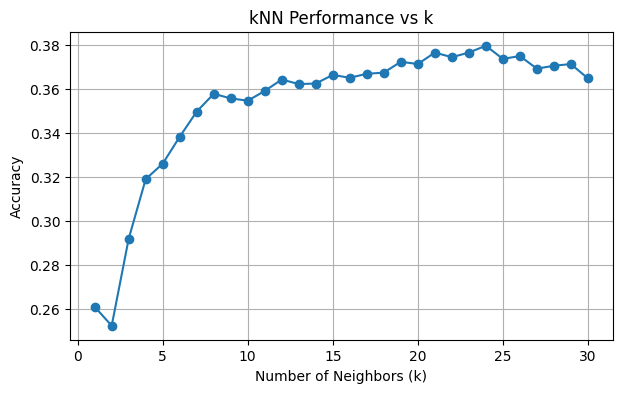

In [36]:
plt.figure(figsize=(7,4))

plt.plot(k_values, results, marker='o')

plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Accuracy")
plt.title("kNN Performance vs k")

plt.grid(True)

plt.show()

LOCO

In [37]:
compound_ids = y[:,1]
compound_enc = LabelEncoder().fit_transform(compound)

In [38]:
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

logo = LeaveOneGroupOut()

k_values = range(1, 31)   # test k from 1 to 30
k_scores = []

for k in k_values:

    knn = KNeighborsClassifier(n_neighbors=k, metric="cosine")

    scores = []

    for train_idx, test_idx in logo.split(X_embeddings, y_enc, groups=compound_ids):

        X_train, X_test = X_embeddings[train_idx], X_embeddings[test_idx]
        y_train, y_test = y_enc[train_idx], y_enc[test_idx]

        knn.fit(X_train, y_train)

        acc = knn.score(X_test, y_test)

        scores.append(acc)

    mean_score = np.mean(scores)
    k_scores.append(mean_score)

    print(f"k = {k}, LOCO accuracy = {mean_score:.4f}")

k = 1, LOCO accuracy = 0.0291
k = 2, LOCO accuracy = 0.0211
k = 3, LOCO accuracy = 0.0273
k = 4, LOCO accuracy = 0.0291
k = 5, LOCO accuracy = 0.0313
k = 6, LOCO accuracy = 0.0256
k = 7, LOCO accuracy = 0.0253
k = 8, LOCO accuracy = 0.0232
k = 9, LOCO accuracy = 0.0228
k = 10, LOCO accuracy = 0.0245
k = 11, LOCO accuracy = 0.0274
k = 12, LOCO accuracy = 0.0242
k = 13, LOCO accuracy = 0.0235
k = 14, LOCO accuracy = 0.0221
k = 15, LOCO accuracy = 0.0256
k = 16, LOCO accuracy = 0.0256
k = 17, LOCO accuracy = 0.0264
k = 18, LOCO accuracy = 0.0256
k = 19, LOCO accuracy = 0.0264
k = 20, LOCO accuracy = 0.0285
k = 21, LOCO accuracy = 0.0278
k = 22, LOCO accuracy = 0.0299
k = 23, LOCO accuracy = 0.0278
k = 24, LOCO accuracy = 0.0285
k = 25, LOCO accuracy = 0.0292
k = 26, LOCO accuracy = 0.0278
k = 27, LOCO accuracy = 0.0292
k = 28, LOCO accuracy = 0.0313
k = 29, LOCO accuracy = 0.0321
k = 30, LOCO accuracy = 0.0292


In [39]:
best_k = k_values[np.argmax(k_scores)]
best_score = max(k_scores)

print("Best k:", best_k)
print("Best LOCO accuracy:", best_score)

Best k: 29
Best LOCO accuracy: 0.03205128205128205


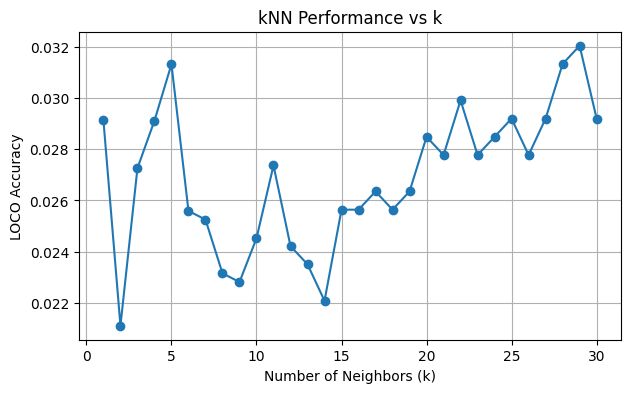

In [40]:
plt.figure(figsize=(7,4))

plt.plot(k_values, k_scores, marker='o')

plt.xlabel("Number of Neighbors (k)")
plt.ylabel("LOCO Accuracy")
plt.title("kNN Performance vs k")

plt.grid(True)

plt.show()

Saving Embeddings

In [41]:
mae_df = pd.DataFrame(X_embeddings, columns=[f"PC{i}" for i in range(1, X_embeddings.shape[1] + 1)])
mae_df["moa"] = moa
mae_df["compound"] = compound
mae_df["concentration"] = concentration

mae_df.to_csv(os.path.join(PROCESSED_DIR, "mae_embeddings.csv"), index=False)

Visualisations

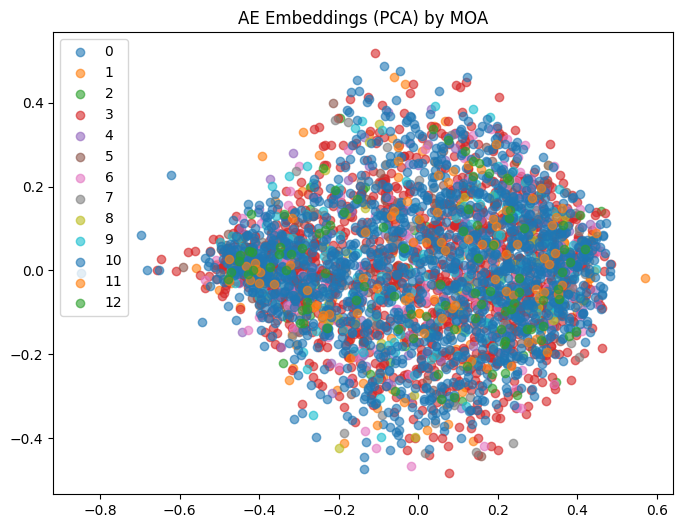

In [43]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

pca = PCA(n_components=2)
emb_2d = pca.fit_transform(X_embeddings)

plt.figure(figsize=(8,6))

for moa in np.unique(y_enc):
    idx = y_enc == moa
    plt.scatter(emb_2d[idx, 0], emb_2d[idx, 1], label=str(moa), alpha=0.6)

plt.legend()
plt.title("AE Embeddings (PCA) by MOA")
plt.show()

UMAP Visualization

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


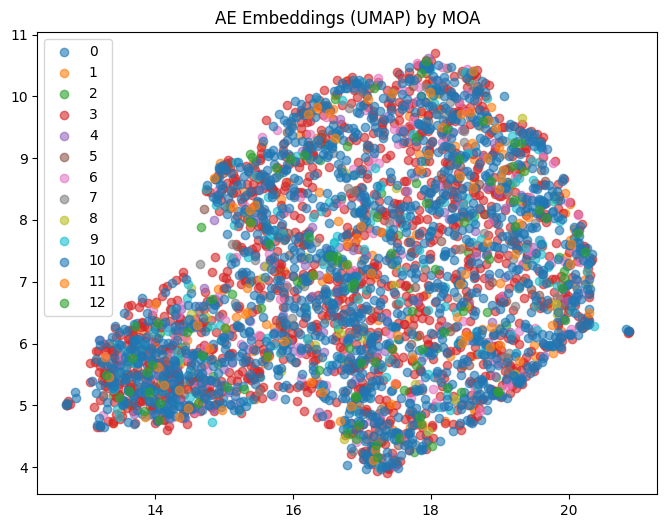

In [44]:
import umap

reducer = umap.UMAP(n_components=2, random_state=42)
emb_2d = reducer.fit_transform(X_embeddings)

plt.figure(figsize=(8,6))

for moa in np.unique(y_enc):
    idx = y_enc == moa
    plt.scatter(emb_2d[idx, 0], emb_2d[idx, 1], label=str(moa), alpha=0.6)

plt.legend()
plt.title("AE Embeddings (UMAP) by MOA")
plt.show()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


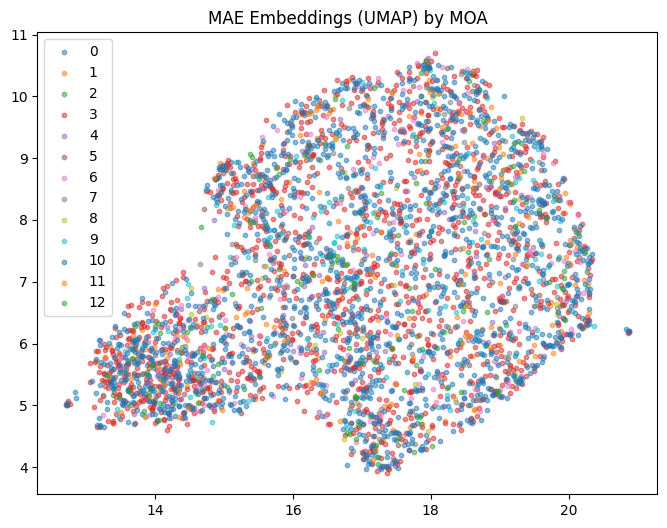

In [45]:
import umap
import matplotlib.pyplot as plt
import numpy as np

reducer = umap.UMAP(n_components=2, random_state=42)
emb_2d = reducer.fit_transform(X_embeddings)

plt.figure(figsize=(8,6))

for moa in np.unique(y_enc):
    idx = y_enc == moa
    plt.scatter(emb_2d[idx, 0], emb_2d[idx, 1], label=str(moa), alpha=0.5, s=10)

plt.legend()
plt.title("MAE Embeddings (UMAP) by MOA")
plt.show()

Percent Replicating

In [46]:
from sklearn.metrics.pairwise import cosine_similarity
def percent_replicating(embeddings, replicate_groups):

    sim = cosine_similarity(embeddings)

    replicate_scores = []
    null_scores = []

    n = len(replicate_groups)

    for i in range(n):
        for j in range(i+1, n):

            if replicate_groups[i] == replicate_groups[j]:
                replicate_scores.append(sim[i, j])
            else:
                null_scores.append(sim[i, j])

    threshold = np.percentile(null_scores, 95)

    replicating = np.sum(np.array(replicate_scores) > threshold)

    percent = replicating / len(replicate_scores)

    return percent

In [47]:
mae_rep = percent_replicating(X_embeddings, replicate_groups)


print("PCA percent replicating:", mae_rep)


PCA percent replicating: 0.048553478279155786
